In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Generate synthetic data
np.random.seed(42)  # ensures reproducibility (you get the same random numbers every time).
X = 2 * np.random.rand(100, 1)  # 100 data points, single feature
y = 3 * X.flatten() + 5 + np.random.randn(100)

In [3]:
#  2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# 3. Scale features (important for SGD!). Why Scale? Because large values can make GD unstable or very slow
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # computes the mean and standard deviation on training data and scales it.
X_test_scaled = scaler.transform(X_test)          # applies the same scaling to the test data (using training set parameters).

In [5]:
# Create SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.1, learning_rate='constant', random_state=42)
sgd_reg.fit(X_train_scaled, y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [6]:
# 5. Print learned parameters
print("Slope (m):", sgd_reg.coef_[0])
print("Intercept (b):", sgd_reg.intercept_[0])

Slope (m): 1.7120409981283247
Intercept (b): 7.610177585905959


In [7]:
# 6. Make predictions
y_pred = sgd_reg.predict(X_test_scaled)

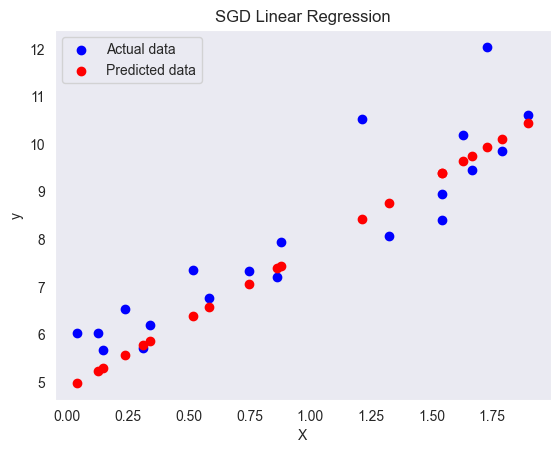

In [9]:
# 7. Plot the results
plt.scatter(X_test, y_test, color='blue', label='Actual data')
plt.scatter(X_test, y_pred, color='red', label='Predicted data')
plt.title("SGD Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()